# VaR backtesting

Compare three 99% VaR models on SPY daily returns:

- **HS**: historical simulation over a 500-day window
- **EWMA normal**: EWMA volatility (λ = 0.94) with a normal quantile
- **EWMA t**: EWMA volatility with a unit-variance Student-t quantile (ν = 5)

For each model we count the breaches (days the loss was bigger than the VaR forecast) and run three tests:

- **Kupiec**: is the breach rate consistent with `alpha`?
- **Christoffersen**: are breaches independent, or does a breach make another one tomorrow more likely?
- **Conditional coverage**: both at once (the two LR statistics added, χ² with 2 degrees of freedom)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# make src/ importable whether the notebook runs from the repo root or notebooks/
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(root / "src"))

from backtesting import christoffersen, conditional_coverage, exceedance, kupiec, summary
from data import clean_prices, download_prices, to_returns
from model import ewma_vol, hs_var, param_var

## Data

In [2]:
prices = clean_prices(download_prices(["SPY"]))
returns = to_returns(prices)["SPY"]
returns.describe()

[*********************100%***********************]  1 of 1 completed

Index(['SPY'], dtype='str', name='Ticker')
dropped: 0 rows with all missing values


count    4215.000000
mean        0.000585
std         0.010735
min        -0.109424
25%        -0.003708
50%         0.000699
75%         0.005791
max         0.105019
Name: SPY, dtype: float64

## VaR forecasts

Every model already shifts its estimate by one day, so `var[t]` only uses returns up to `t - 1`. The backtest compares it directly with `returns[t]`, with no extra shift.

HS needs 450 days of history before it produces a number, while EWMA needs only 30. To compare like with like, all three models are cut to the dates where every one of them has a forecast.

In [3]:
ALPHA = 0.01

sigma = ewma_vol(returns)
var = pd.DataFrame(
    {
        "HS": hs_var(returns, alpha=ALPHA),
        "EWMA normal": param_var(sigma, alpha=ALPHA, dist="normal"),
        "EWMA t": param_var(sigma, alpha=ALPHA, dist="t", nu=5),
    }
).dropna()
returns_bt = returns.loc[var.index]

print(f"backtest window: {var.index[0]:%Y-%m-%d} to {var.index[-1]:%Y-%m-%d}, {len(var)} days")

backtest window: 2011-10-17 to 2026-10-07, 3765 days


## Breaches and coverage tests

A p-value below 0.05 rejects the model. Kupiec fails models in both directions, so too few breaches (an overly conservative VaR) is a failure too. Christoffersen only looks at whether breaches depend on the previous day, so a model can pass it with far too many breaches, as long as they're spread out.

In [4]:
hits = {name: exceedance(returns_bt, var[name]) for name in var.columns}

TESTS = {
    "kupiec": lambda h: kupiec(h, ALPHA),
    "christoffersen": lambda h: christoffersen(h, ALPHA),
    "cond_coverage": lambda h: conditional_coverage(h, ALPHA),
}

rows = []
for name, h in hits.items():
    row = {"model": name, **summary(h, ALPHA)}
    for test, func in TESTS.items():
        row[f"{test}_p"] = func(h)[1]
    rows.append(row)

results = pd.DataFrame(rows).set_index("model")
verdicts = (results[[f"{t}_p" for t in TESTS]] < 0.05).replace({True: "reject", False: "pass"})
verdicts.columns = list(TESTS)

display(results.round({"expected": 1, "hit_rate": 4}).round(4))
verdicts

,n,exceedances,expected,hit_rate,kupiec_p,christoffersen_p,cond_coverage_p
model,,,,,,,
HS,3765,50,37.6,0.0133,0.0541,0.0000,0.0
EWMA normal,3765,85,37.6,0.0226,0.0000,0.0149,0.0
EWMA t,3765,65,37.6,0.0173,0.0000,0.0056,0.0


,kupiec,christoffersen,cond_coverage
model,,,
HS,pass,reject,reject
EWMA normal,reject,reject,reject
EWMA t,reject,reject,reject


## Returns against VaR

Each panel shows the daily return in grey, the negative VaR forecast as a line, and breaches as dots. Look at how fast each model's line reacts to the March 2020 crash: HS barely moves, so its breaches pile up in a few weeks. EWMA widens within days.

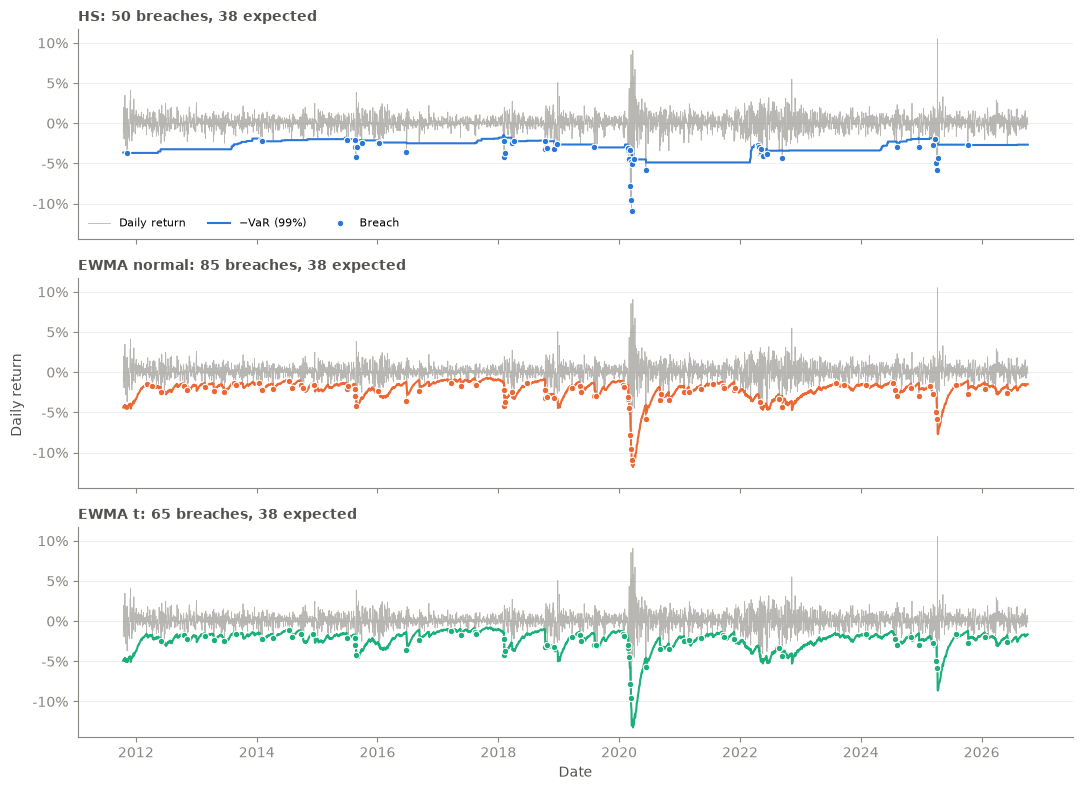

In [5]:
# reference palette, categorical slots 1-3
COLORS = {"HS": "#2a78d6", "EWMA normal": "#eb6834", "EWMA t": "#1baf7a"}
MUTED, INK = "#898781", "#52514e"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
})

fig, axes = plt.subplots(len(COLORS), 1, figsize=(11, 8), sharex=True, sharey=True)
for ax, (name, color) in zip(axes, COLORS.items()):
    h = hits[name]
    ax.plot(returns_bt.index, returns_bt, color=MUTED, lw=0.6, alpha=0.6, label="Daily return")
    ax.plot(var.index, -var[name], color=color, lw=1.5, label="−VaR (99%)")
    ax.scatter(
        returns_bt.index[h], returns_bt[h], s=22, color=color,
        edgecolor="white", linewidth=0.8, zorder=3, label="Breach",
    )
    ax.set_title(f"{name}: {int(h.sum())} breaches, {ALPHA * len(h):.0f} expected", fontsize=10)
    ax.grid(axis="y", color=MUTED, alpha=0.2, lw=0.5)
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")

axes[0].legend(loc="lower left", frameon=False, fontsize=8, ncols=3)
axes[-1].set_xlabel("Date")
fig.supylabel("Daily return", color=INK, fontsize=10)
fig.tight_layout()
plt.show()

## Breaches per year

The Kupiec test only counts breaches, so it can't see clustering. Counting them by year shows it: a good model's breaches are spread out, and a slow model's pile up in crisis years. The dashed line is the expected count per year (about 2.5 at 99%).

The Christoffersen test turns this into a formal check.

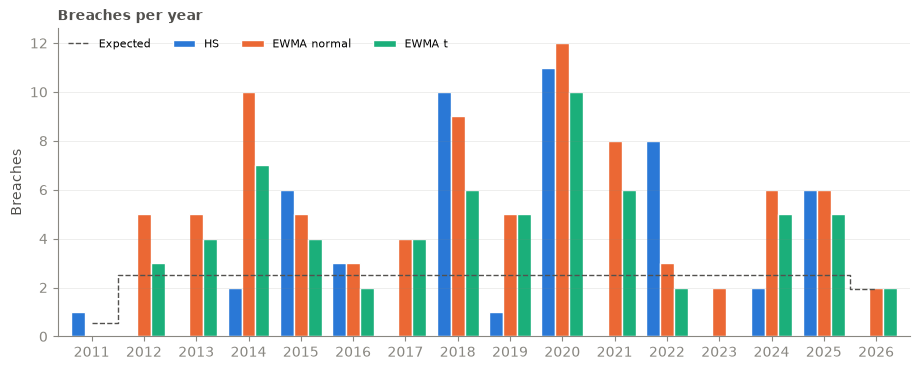

,HS,EWMA normal,EWMA t,days
Date,,,,
2011,1,0,0,53
2012,0,5,3,250
2013,0,5,4,252
2014,2,10,7,252
2015,6,5,4,252
2016,3,3,2,252
2017,0,4,4,251
2018,10,9,6,251
2019,1,5,5,252


In [6]:
by_year = pd.DataFrame(hits).groupby(lambda d: d.year).sum()
days_per_year = pd.DataFrame(hits).groupby(lambda d: d.year).size()

ax = by_year.plot.bar(
    figsize=(11, 4), width=0.8, color=[COLORS[c] for c in by_year.columns],
    edgecolor="white", linewidth=1,
)
ax.step(
    range(len(days_per_year)), ALPHA * days_per_year, where="mid",
    color=INK, ls="--", lw=1, label="Expected",
)
ax.set_title("Breaches per year", fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("Breaches")
ax.grid(axis="y", color=MUTED, alpha=0.2, lw=0.5)
ax.legend(frameon=False, fontsize=8, ncols=4)
plt.xticks(rotation=0)
plt.show()

by_year.assign(days=days_per_year)

## Takeaways

These numbers are from SPY 2011-2026 at 99%. Rerun to refresh them.

- **EWMA fails on the count, not just on clustering.** With λ = 0.94 it reacts fast, but it also forgets crashes within weeks, and its VaR drops too low in calm markets. A third of its breaches (28 of 85) fall in calm years like 2012-2014 and 2021, not in crises. That's the known weakness of RiskMetrics-style EWMA at 99%.
- **The t distribution helps but doesn't fix it.** Fatter tails cut breaches from 85 to 65, but the problem is the volatility forecast, not the tail shape.
- **HS passes Kupiec only just, but fails Christoffersen hard (p ≈ 3e-6).** After a breach, the chance of another breach the next day is 14% (7 of 50), against about 1.2% after a normal day. Its VaR is almost flat, so breaches pile into 2018, 2020 and 2022. This is the case Kupiec can't see.
- **EWMA clusters too, just less.** After a breach, the chance of another is 7-8% against about 2% otherwise, so it fails Christoffersen at p = 0.015 (normal) and p = 0.006 (t). EWMA reacts to a shock within days, but not by enough on the second day of a crash.
- **No model passes conditional coverage.** HS has the right count but clusters; EWMA has too many and clusters.
- **What to try:** a slower decay (λ = 0.97-0.99), a lower ν, or GARCH, whose variance reverts to a long-run level instead of collapsing in calm periods.